In [1]:
import pandas as pd  # 데이터 처리
import glob  # 파일 일괄 로드
import matplotlib.pyplot as plt  # 시각화 라이브러리
import matplotlib as mpl  # 폰트 설정용

# 윈도우 기본 한글 폰트 설정
mpl.rcParams["font.family"] = "Malgun Gothic"  # 맑은 고딕 사용

# 마이너스 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False  # 음수 기호 정상 출력

In [2]:
# 1. match_meta
meta_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_detail\match_meta\*.parquet"
match_meta_df = pd.concat([pd.read_parquet(f) for f in glob.glob(meta_path)], ignore_index=True)

# 2. participants
participants_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_detail\participants\*.parquet"
participants_df = pd.concat([pd.read_parquet(f) for f in glob.glob(participants_path)], ignore_index=True)

# 3. teams
teams_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_detail\teams\*.parquet"
teams_df = pd.concat([pd.read_parquet(f) for f in glob.glob(teams_path)], ignore_index=True)

# 4. events
events_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_timeline\events\*.parquet"
events_df = pd.concat([pd.read_parquet(f) for f in glob.glob(events_path)], ignore_index=True)

# 5. frames
frames_path = r"F:\porti\2025\스파르타자료들\python_study\venv\04_Team8\0.googledrive\match_timeline\frames\*.parquet"
frames_df = pd.concat([pd.read_parquet(f) for f in glob.glob(frames_path)], ignore_index=True)

In [ ]:
# 정상 경기 + 15분 이상 경기 match_id 추출

duration_col = "game_duration"      # 실제 컬럼명 확인해서 수정
result_col = "end_of_game_result"     # 실제 컬럼명 확인해서 수정

# 단위 자동 판단
if match_meta_df[duration_col].mean() > 100000:
    min_duration = 900000   # ms
else:
    min_duration = 900      # sec

valid_matches = match_meta_df[
    (match_meta_df[duration_col] >= min_duration) &
    (match_meta_df[result_col] == "GameComplete")
]["match_id"]

# 메모리 효율 위해 set 변환
valid_set = set(valid_matches)

print("필터 후 경기 수:", len(valid_set))

import gc

filtered_frames = []

for file in glob.glob(frames_path):
    
    temp = pd.read_parquet(
        file,
        columns=["match_id","timestamp","participant_id","total_gold"]  # 필요한 컬럼만
    )
    
    temp = temp[temp["match_id"].isin(valid_set)]
    
    if len(temp) > 0:
        filtered_frames.append(temp)
    
    del temp
    gc.collect()

frames_df = pd.concat(filtered_frames, ignore_index=True)

print("frames 필터 후 행 수:", len(frames_df))

filtered_participants = []

for file in glob.glob(participants_path):
    
    temp = pd.read_parquet(
        file,
        columns=["match_id","participant_id","team_id"]
    )
    
    temp = temp[temp["match_id"].isin(valid_set)]
    
    if len(temp) > 0:
        filtered_participants.append(temp)
    
    del temp
    gc.collect()

participants_df = pd.concat(filtered_participants, ignore_index=True)

print("participants 필터 후 행 수:", len(participants_df))

filtered_teams = []

for file in glob.glob(teams_path):
    
    temp = pd.read_parquet(
        file,
        columns=["match_id","team_id","win"]
    )
    
    temp = temp[temp["match_id"].isin(valid_set)]
    
    if len(temp) > 0:
        filtered_teams.append(temp)
    
    del temp
    gc.collect()

teams_df = pd.concat(filtered_teams, ignore_index=True)

print("teams 필터 후 행 수:", len(teams_df))

filtered_events = []

for file in glob.glob(events_path):
    
    temp = pd.read_parquet(
        file,
        columns=["match_id","timestamp","event_type","killer_id","victim_id","team_id"]
    )
    
    temp = temp[temp["match_id"].isin(valid_set)]
    
    if len(temp) > 0:
        filtered_events.append(temp)
    
    del temp
    gc.collect()

events_df = pd.concat(filtered_events, ignore_index=True)

print("events 필터 후 행 수:", len(events_df))

필터 후 경기 수: 109274


In [3]:
# frames에 team_id 붙이기
frames_team = frames_df.merge(participants_df[["match_id","participant_id","team_id"]],on=["match_id","participant_id"],how="left")

In [4]:
# 10분 열세 시 승률

# 10분 팀 골드 계산 (10분 = 600000ms)
# match_id 기준으로 10분에 가장 가까운 timestamp 계산
frames_team["time_diff"] = (frames_team["timestamp"] - 600000).abs()

# match별 최소 time_diff만 남기기
min_time = frames_team.groupby("match_id")["time_diff"].transform("min")

# 10분에 가장 가까운 프레임만 필터링
closest_10 = frames_team[frames_team["time_diff"] == min_time]

# 팀별 골드 합산
gold_10 = closest_10.groupby(["match_id","team_id"])["total_gold"].sum().reset_index()

# 팀 2개가 모두 존재하는 경기만 남기기
gold_10 = gold_10.groupby("match_id").filter(lambda x: x["team_id"].nunique()==2)

# pivot 생성
pivot_10 = gold_10.pivot(index="match_id", columns="team_id", values="total_gold").reset_index()

# match_id 제외한 팀 컬럼 추출
team_cols = [c for c in pivot_10.columns if c != "match_id"]

# 팀 컬럼이 2개인지 강제 확인
print("team_cols:", team_cols)

# 골드 차이 계산
pivot_10["gold_diff"] = pivot_10[team_cols[0]] - pivot_10[team_cols[1]]

# 열세 팀 판별
pivot_10["losing_team"] = pivot_10.apply(lambda row: team_cols[0] if row["gold_diff"] < 0 else team_cols[1], axis=1)

# 열세 팀 승패 merge
result_10 = pivot_10.merge(teams_df[["match_id","team_id","win"]], left_on=["match_id","losing_team"], right_on=["match_id","team_id"], how="left")
print("10분 열세 팀 승률:", result_10["win"].mean())

team_cols: [100, 200]
10분 열세 팀 승률: 0.3045336469266683


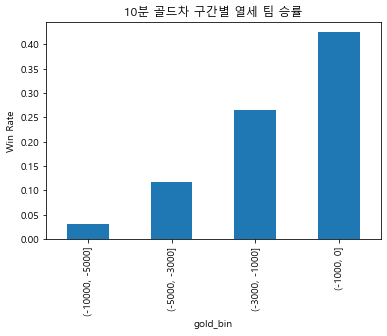

In [5]:
# 골드차 구간별 승률 시각화
# 골드차 구간 설정
bins = [-10000,-5000,-3000,-1000,0]

# 구간 생성
pivot_10["gold_bin"] = pd.cut(pivot_10["gold_diff"],bins)

# 구간별 승률 계산
bin_result = pivot_10.merge(teams_df[["match_id","team_id","win"]], left_on=["match_id","losing_team"], right_on=["match_id","team_id"])

win_by_bin = bin_result.groupby("gold_bin")["win"].mean()

# 시각화
win_by_bin.plot(kind="bar")
plt.title("10분 골드차 구간별 열세 팀 승률")
plt.ylabel("Win Rate")
plt.show()

In [6]:
# 첫 오브젝트 전용 events만 처리
event_files = glob.glob(events_path)
filtered_list = []  # 결과 저장용

In [7]:
# 파일 하나씩 순회하며 메모리 안전하게 처리
for file in event_files:  # 파일 반복
    temp = pd.read_parquet(file, columns=["match_id","timestamp","team_id","event_type"])  # 필요한 컬럼만 로드
    temp = temp[temp["event_type"].isin(["ELITE_MONSTER_KILL","BUILDING_KILL"])]  # 오브젝트 이벤트만 필터
    filtered_list.append(temp)  # 리스트에 저장

In [8]:
object_events = pd.concat(filtered_list, ignore_index=True)  # 필요한 데이터만 결합

In [9]:
# 첫 오브젝트 이후 승률

# 경기별 첫 오브젝트 추출
first_object = object_events.sort_values("timestamp").groupby("match_id").first().reset_index()

# 승패 merge
first_object = first_object.merge(teams_df[["match_id","team_id","win"]], on=["match_id","team_id"], how="left")
print("첫 오브젝트 팀 승률:", first_object["win"].mean())

첫 오브젝트 팀 승률: 0.3001997318668089


10분 5데스 이상 팀 승률: 0.44179807470531823


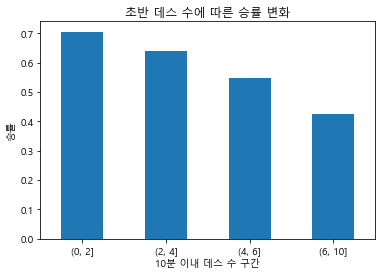

In [10]:
# 초반 다수 데스 조건부 승률

# 10분 이내 킬 이벤트
kill_list = []  # 필요한 이벤트만 저장

for file in event_files:  # 파일 반복
    temp = pd.read_parquet(file, columns=["match_id","timestamp","event_type","victim_id"])  # 필요한 컬럼만 로드
    temp = temp[(temp["event_type"]=="CHAMPION_KILL") & (temp["timestamp"]<=600000)]  # 10분 이내 킬 필터
    kill_list.append(temp)  # 리스트에 추가

early_kill = pd.concat(kill_list, ignore_index=True)  # 필요한 데이터만 결합

early_kill = early_kill.merge(
    participants_df[["match_id","participant_id","team_id"]],
    left_on=["match_id","victim_id"],
    right_on=["match_id","participant_id"],
    how="left"
)

# 팀별 데스 집계
death_count = early_kill.groupby(["match_id","team_id"]).size().reset_index(name="early_deaths")

# 승패 merge
death_count = death_count.merge(teams_df[["match_id","team_id","win"]], on=["match_id","team_id"])
print("10분 5데스 이상 팀 승률:", death_count[death_count["early_deaths"]>=5]["win"].mean())

# 데스 구간 설정
death_count["데스_구간"] = pd.cut(death_count["early_deaths"], [0,2,4,6,10])  # 데스 구간화

# 구간별 승률 계산
death_percent = death_count.groupby("데스_구간")["win"].mean()  # 평균 승률 계산

# 시각화
death_percent.plot(kind="bar")  # 막대그래프
plt.title("초반 데스 수에 따른 승률 변화")  # 제목
plt.xlabel("10분 이내 데스 수 구간")  # x축
plt.ylabel("승률")  # y축
plt.xticks(rotation=0)  # 글자 회전 제거
plt.show()  # 출력

In [90]:
print("early_kill 행 수:", len(early_kill))  # 10분 이내 킬 개수 확인
print("death_count 행 수:", len(death_count))  # 팀별 집계 개수 확인
print(death_count.head())  # 실제 데이터 확인

early_kill 행 수: 1485425
death_count 행 수: 0
Empty DataFrame
Columns: [early_deaths, match_id, team_id, win, 데스_구간]
Index: []


In [92]:
# 복구 조건부 승률 (열세 + 첫 오브젝트)

# 열세 팀 + 첫 오브젝트 동시 만족
recover_case = result_10.merge(
    first_object[["match_id","team_id"]],
    left_on=["match_id","losing_team"],
    right_on=["match_id","team_id"],
    how="inner"
)

# 승률 계산 (이미 result_10에 win 존재)
print("열세 + 첫 오브젝트 팀 승률:", recover_case["win"].mean())

열세 + 첫 오브젝트 팀 승률: 0.22725998419858806


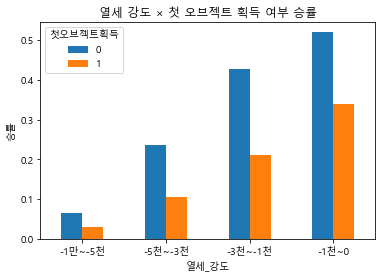

In [11]:
# 열세 강도에 따른 복구 가능성 구조화

# 열세 강도 구간 재설정 (양수 절댓값 기준)
pivot_10["열세_강도"] = pd.cut(
    pivot_10["gold_diff"],
    bins=[-10000,-5000,-3000,-1000,0],
    labels=["-1만~-5천","-5천~-3천","-3천~-1천","-1천~0"]
)

# 열세 팀 기준 승패 데이터
losing_win = result_10[["match_id","losing_team","win","gold_diff"]]

# 첫 오브젝트 여부 표시
losing_win = losing_win.merge(
    first_object[["match_id","team_id"]],
    left_on=["match_id","losing_team"],
    right_on=["match_id","team_id"],
    how="left",
    indicator="first_obj_flag"
)

losing_win["첫오브젝트획득"] = losing_win["first_obj_flag"].apply(lambda x: 1 if x=="both" else 0)

# 열세 강도 merge
losing_win = losing_win.merge(
    pivot_10[["match_id","열세_강도"]],
    on="match_id"
)

# 교차 승률
cross_result = losing_win.groupby(["열세_강도","첫오브젝트획득"])["win"].mean().unstack()

# 시각화
cross_result.plot(kind="bar")
plt.title("열세 강도 × 첫 오브젝트 획득 여부 승률")
plt.ylabel("승률")
plt.xticks(rotation=0)
plt.show()

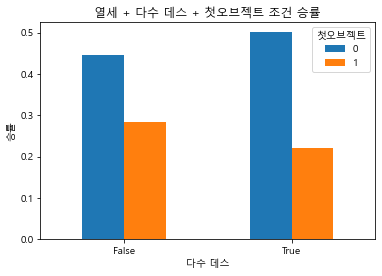

In [13]:
# 5데스 이상 팀 표시
death_flag = death_count.copy()
death_flag["다수 데스"] = death_flag["early_deaths"]>=5

# 열세팀 기준 merge
combo = result_10.merge(
    death_flag[["match_id","team_id","다수 데스"]],
    left_on=["match_id","losing_team"],
    right_on=["match_id","team_id"],
    how="left"
)

# 첫 오브젝트 여부 merge
combo = combo.merge(
    first_object[["match_id","team_id"]],
    left_on=["match_id","losing_team"],
    right_on=["match_id","team_id"],
    how="left",
    indicator="obj_flag"
)

combo["첫오브젝트"] = combo["obj_flag"].apply(lambda x: 1 if x=="both" else 0)

# 조건별 승률
triple_result = combo.groupby(["다수 데스","첫오브젝트"])["win"].mean().unstack()

triple_result.plot(kind="bar")
plt.title("열세 + 다수 데스 + 첫오브젝트 조건 승률")
plt.ylabel("승률")
plt.xticks(rotation=0)
plt.show()

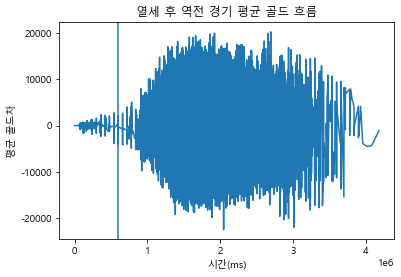

In [17]:
# 열세지만 최종 승리한 경기
comeback_matches = result_10[result_10["win"]==1]["match_id"]

# 해당 경기 프레임 추출
comeback_frames = frames_team[frames_team["match_id"].isin(comeback_matches)]

# 팀별 골드 합
gold_flow = comeback_frames.groupby(["timestamp","match_id","team_id"])["total_gold"].sum().reset_index()

# 경기별 골드차 계산
gold_flow_pivot = gold_flow.pivot_table(index=["timestamp","match_id"], columns="team_id", values="total_gold")

team_cols = gold_flow_pivot.columns.tolist()
gold_flow_pivot["gold_diff"] = gold_flow_pivot[team_cols[0]] - gold_flow_pivot[team_cols[1]]

# 시간별 평균
mean_flow = gold_flow_pivot.groupby("timestamp")["gold_diff"].mean()

mean_flow.plot()
plt.axvline(600000)
plt.title("열세 후 역전 경기 평균 골드 흐름")
plt.ylabel("평균 골드차")
plt.xlabel("시간(ms)")
plt.show()

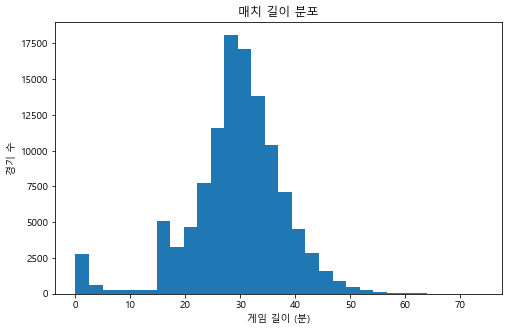

평균 경기 길이: 29.303776847609996


In [19]:
# match 길이 계산 (frames 기준 최대 timestamp 사용)
match_length = frames_df.groupby("match_id")["timestamp"].max().reset_index()

# 분 단위 변환
match_length["minute"] = match_length["timestamp"] / 60000

# 시각화
plt.figure(figsize=(8,5))
plt.hist(match_length["minute"], bins=30)
plt.title("매치 길이 분포")
plt.xlabel("게임 길이 (분)")
plt.ylabel("경기 수")
plt.show()

print("평균 경기 길이:", match_length["minute"].mean())

In [20]:
# 경기 종료 시 팀 골드
final_frame = frames_team.sort_values("timestamp").groupby(["match_id","team_id"]).last().reset_index()

plt.figure(figsize=(8,5))
plt.hist(final_frame["total_gold"], bins=30)
plt.title("팀 최종 골드 분포")
plt.xlabel("최종 골드")
plt.ylabel("팀 수")
plt.show()

print("평균 최종 골드:", final_frame["total_gold"].mean())

MemoryError: Unable to allocate 268. MiB for an array with shape (35092680,) and data type int64